A5 data analytics II 
1. implement logistic regression using python/r to perform classification on social_network_ads.csv dataset.
2. compute confusion matrix to find tp, fp, tn, fn, accuracy, error rate, precision, recall on the given dataset.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, accuracy_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns

df= pd.read_csv(r"C:\Users\HP\Downloads\Social_Network_Ads.csv")
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [2]:
df.info

<bound method DataFrame.info of      Age  EstimatedSalary  Purchased
0     19            19000          0
1     35            20000          0
2     26            43000          0
3     27            57000          0
4     19            76000          0
..   ...              ...        ...
395   46            41000          1
396   51            23000          1
397   50            20000          1
398   36            33000          0
399   49            36000          1

[400 rows x 3 columns]>

In [9]:
X=df[['Age', 'EstimatedSalary']]  #features/independent variables
y=df['Purchased']      # target/dependent variable

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.35, random_state=42)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test= sc.transform(X_test)

In [10]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred= model.predict(X_test)

print("Accuracy: ", accuracy_score(y_test,y_pred))
print("Error rate: " , 1-  accuracy_score(y_test,y_pred))
print("Recall: ", recall_score(y_test,y_pred))
print("Precision: ", precision_score(y_test,y_pred))

Accuracy:  0.8357142857142857
Error rate:  0.16428571428571426
Recall:  0.625
Precision:  0.9459459459459459


<Axes: >

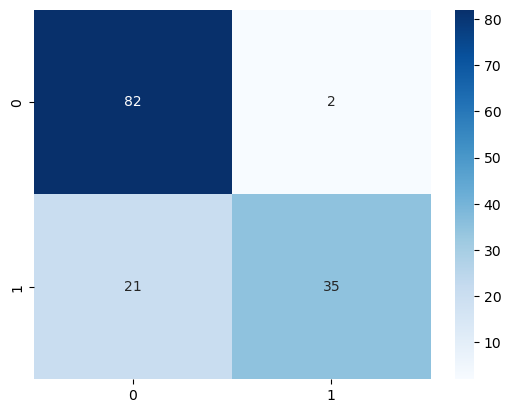

In [13]:
cm= confusion_matrix(y_test, y_pred)

TN, FP, FN,TP = cm.ravel()

sns.heatmap(cm, annot=True, fmt = 'd', cmap = 'Blues')

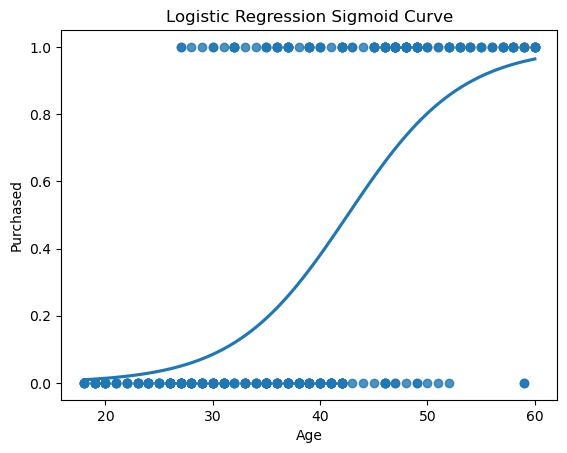

In [16]:
sns.regplot(
    x='Age',
    y='Purchased',
    data=df,
    logistic=True,
    ci=None
)

plt.xlabel("Age")
plt.ylabel("Purchased")

plt.title("Logistic Regression Sigmoid Curve")

plt.show()